In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ROUNDS = 20
LOCAL_EPOCHS = 1

all_exp = pd.read_csv("experiment.csv")
selected_exp = (
    all_exp[(all_exp["rounds"] == ROUNDS) & (all_exp["local_epochs"] == LOCAL_EPOCHS)]
    .copy()
    .iloc[0]
)

out_dir = selected_exp["out_dir"].replace("andrea/", "")

client_df = pd.read_csv(out_dir + "/client.csv")
fedavg_df = pd.read_csv(out_dir + "/fedavg.csv")
local_df = pd.read_csv(out_dir + "/local.csv")

print(len(client_df))
print(len(fedavg_df))
print(len(local_df))

1700
800
900


In [117]:
def safe_div(num, den):
    return np.where(den > 0, num / den, 0.0)

def f1_from_counts(tp, fp, fn):
    precision = safe_div(tp, tp + fp)
    recall = safe_div(tp, tp + fn)
    f1 = safe_div(2 * precision * recall, precision + recall)
    return precision, recall, f1

clients = [int(x) for x in str(selected_exp["subset_clients"]).split("|")]
print("Clients:", clients)

Clients: [5, 6, 9, 10, 14]


In [155]:
print(set(client_df["phase"]))
# client data
client_pre_val = client_df[client_df["phase"] == "pre_local_val"].copy()
client_post_val = client_df[client_df["phase"] == "post_local_val"].copy()
client_training = client_df[client_df["phase"] == "training"].copy()
client_pre_val_task = client_df[client_df["phase"] == "pre_local_val_task"].copy()
client_post_val_task = client_df[client_df["phase"] == "post_local_val_task"].copy()
print(set(fedavg_df["phase"]))
fedavg_val = fedavg_df[fedavg_df["phase"] == "global_val_client"].copy()
fedavg_val_task = fedavg_df[fedavg_df["phase"] == "global_val_client_task"].copy()
print(set(local_df["phase"]))
local_training = local_df[local_df["phase"] == "training"].copy()
local_val = local_df[local_df["phase"] == "val"].copy()
local_val_task = local_df[local_df["phase"] == "val_task"].copy()

{'post_local_val', 'post_local_val_task', 'pre_local_val_task', 'training', 'pre_local_val'}
{'global_val_client_task', 'global_val_client'}
{'val', 'training', 'val_task'}


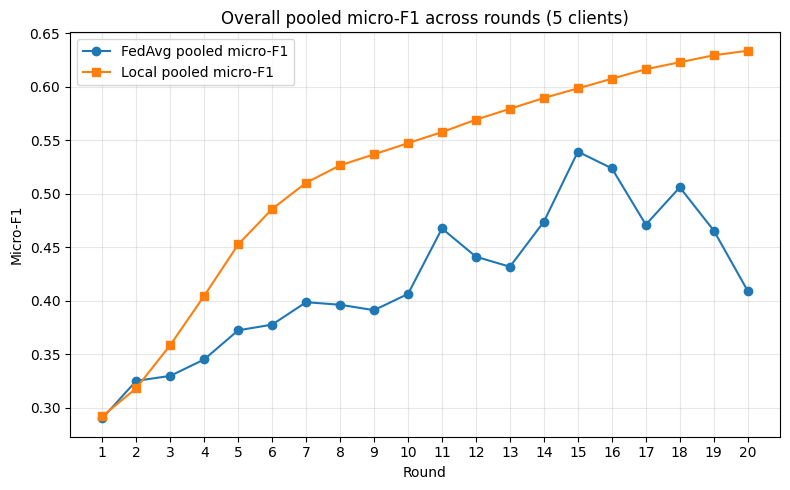

In [152]:
fed_round_micro = (
    fedavg_val_task
    .groupby("round", as_index=False)[["tp", "fp", "fn"]]
    .sum()
    .sort_values("round")
)

local_round_micro = (
    local_val_task
    .groupby("local_epoch", as_index=False)[["tp", "fp", "fn"]]
    .sum()
    .sort_values("local_epoch")
)

fed_round_micro["precision"], fed_round_micro["recall"], fed_round_micro["micro_f1_pooled"] = f1_from_counts(
    fed_round_micro["tp"].values,
    fed_round_micro["fp"].values,
    fed_round_micro["fn"].values,
)

local_round_micro["precision"], local_round_micro["recall"], local_round_micro["micro_f1_pooled"] = f1_from_counts(
    local_round_micro["tp"].values,
    local_round_micro["fp"].values,
    local_round_micro["fn"].values,
)
plt.figure(figsize=(8, 5))

plt.plot(
    fed_round_micro["round"],
    fed_round_micro["micro_f1_pooled"],
    marker="o",
    label="FedAvg pooled micro-F1"
)

plt.plot(
    local_round_micro["local_epoch"],
    local_round_micro["micro_f1_pooled"],
    marker="s",
    label="Local pooled micro-F1"
)

plt.xlabel("Round")
plt.ylabel("Micro-F1")
plt.title(f"Overall pooled micro-F1 across rounds ({len(clients)} clients)")
plt.xticks(sorted(fed_round_micro["round"].unique()))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
fed_round_task_agg = (
    fedavg_val_task
    .groupby(["round", "task", "client_id"], as_index=False)[["tp", "fp", "fn", "tn"]]
    .sum()
    .sort_values(["round", "task"])
)
_, _, fed_round_task_agg["task_f1"] = f1_from_counts(
    fed_round_task_agg["tp"].values,
    fed_round_task_agg["fp"].values,
    fed_round_task_agg["fn"].values,
)
fed_round_macro = (
    fed_round_task_agg
    .groupby("round", as_index=False)["task_f1"]
    .mean()
    .rename(columns={"task_f1": "macro_f1_pooled"})
    .sort_values("round")
)

local_round_task_agg = (
    local_val_task
    .groupby(["local_epoch", "task", "client_id"], as_index=False)[["tp", "fp", "fn", "tn"]]
    .sum()
    .sort_values(["local_epoch", "task"])
)
_, _, local_round_task_agg["task_f1"] = f1_from_counts(
    local_round_task_agg["tp"].values,
    local_round_task_agg["fp"].values,
    local_round_task_agg["fn"].values,
)
local_round_macro = (
    local_round_task_agg
    .groupby("local_epoch", as_index=False)["task_f1"]
    .mean()
    .rename(columns={"task_f1": "macro_f1_pooled"})
    .sort_values("local_epoch")
)

     round    task  client_id   tp   fp   fn      tn
5        1  cycle2          5  0.0  0.0  0.0  1500.0
6        1  cycle2          6  0.0  0.0  0.0  2000.0
7        1  cycle2          9  0.0  0.0  0.0  1000.0
8        1  cycle2         10  0.0  0.0  0.0  2000.0
9        1  cycle2         14  0.0  0.0  0.0  1000.0
..     ...     ...        ...  ...  ...  ...     ...
670     20  cycle2          5  0.0  0.0  0.0  1500.0
671     20  cycle2          6  0.0  0.0  0.0  2000.0
672     20  cycle2          9  0.0  0.0  0.0  1000.0
673     20  cycle2         10  0.0  0.0  0.0  2000.0
674     20  cycle2         14  0.0  0.0  0.0  1000.0

[100 rows x 7 columns]
     local_epoch    task  client_id   tp      fp   fn      tn
5              1  cycle2          5  0.0  1500.0  0.0     0.0
6              1  cycle2          6  0.0     0.0  0.0  2000.0
7              1  cycle2          9  0.0     0.0  0.0  1000.0
8              1  cycle2         10  0.0     0.0  0.0  2000.0
9              1  cycle2      